<a href="https://colab.research.google.com/github/yamunar0504-cloud/Wholesale-Customer-Type-prediction-ML/blob/main/Supervised_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Wholesale Customer Type Prediction - Supervised Learning**

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/Wholesale customers data.csv')
print(df)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  
..          ...

**Explantion Of Each Feature**
-

**Identifing Features(X)-input variables and Label(y)-target varaibles**

In [ ]:
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']


**DataQuality & Preprocessing**-Finding Missing values,Dupliacates in Dataset

In [ ]:
df.isnull()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
435,False,False,False,False,False,False,False,False
436,False,False,False,False,False,False,False,False
437,False,False,False,False,False,False,False,False
438,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


**NOTE**

1.The dataset was checked for missing values using .isnull().sum(), and no missing values were found in any column.

2.All features contain complete observations, ensuring data consistency and reliability.

3.Since no null values were detected, no imputation or missing value treatment was required during preprocessing.

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
435,False
436,False
437,False
438,False


In [ ]:
df.duplicated().sum()

np.int64(0)

**NOTE**

1.The dataset was examined for duplicate records using .duplicated().sum(), and no duplicate rows were identified.

2.Each record in the dataset is unique and represents a distinct customer entry.

3.Therefore, no duplicate removal or deduplication process was necessary.

**Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
df.shape

(440, 8)

**Comparing Spending Patterns Across Customer Types**

In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


**NOTE**

The dataset contains 440 customer records,No missing values are present.

**Mean**

Customers spend highest on Fresh products (Fresh = 12000)

Grocery and Milk also have significant spending.(Grocery=7951,Milk=5796)

**std**

Fresh (std) = 12647

Grocery(std)= 9503

1.Very high standard deviation compared to mean.

2.Large variation in spending.

3.Presence of possible outliers.

4.Data is highly spread and skewed.

**Min vs Max Values**

*Fresh:*
Min = 3, Max = 112151

1.Huge gap between min and max.

2.Outliers present

3.Data is right-skewed

4.Scaling will be required before modeling



**To Identifing the Customers Type**

In [ ]:
df['Channel'].value_counts()

,count
Channel,
1,298
2,142




**channel-1(HORECA)** = 298 customers

**channel-2(Retail)** = 142 customers

The value_counts() function was used to analyze the distribution of the target variable (Channel). The dataset contains more HORECA customers compared to Retail customers. Although there is a slight class imbalance, it is not extreme and does not significantly affect model training. Therefore, the dataset is suitable for supervised classification without requiring resampling techniques.It is suitable for classification modelling.




**Customer Type Distribution**

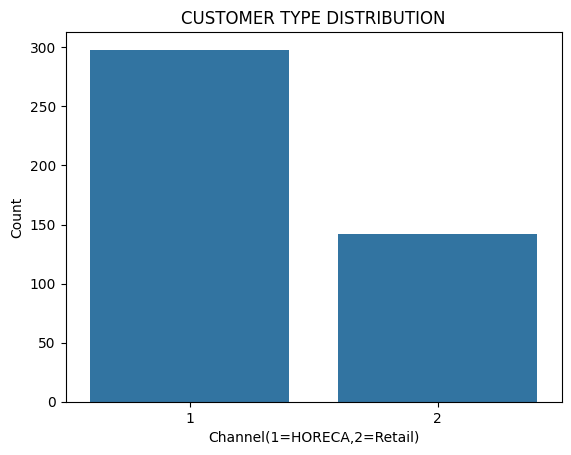

In [ ]:
sns.countplot(x='Channel',data=df)
plt.title('CUSTOMER TYPE DISTRIBUTION')
plt.xlabel('Channel(1=HORECA,2=Retail)')
plt.ylabel('Count')
plt.show()

In [ ]:
df.groupby('Channel').mean()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,,,,,,,
1,2.510067,13475.560403,3451.724832,3962.137584,3748.251678,790.560403,1415.956376
2,2.612676,8904.323944,10716.500000,16322.852113,1652.612676,7269.507042,1753.436620


**NOTE**

- HORECA Customers spends more on **Fresh**.

- Retail Customers spends more on **Glocery, Milk, Fresh, Detergents_Paper**.

**Identifing Product Categories that Differentiate Customers**

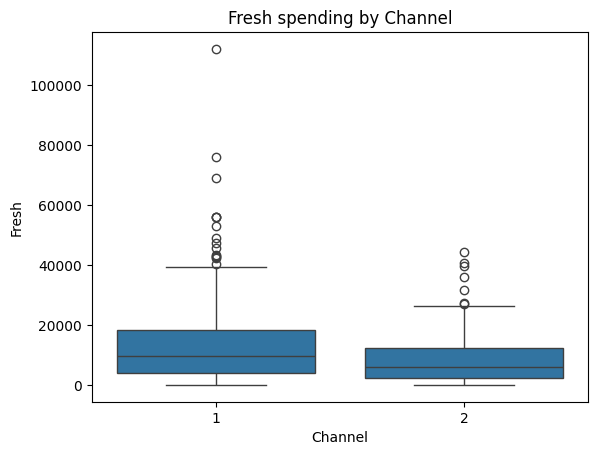

In [ ]:
sns.boxplot(x='Channel',y='Fresh',data=df)
plt.title("Fresh spending by Channel")
plt.show()

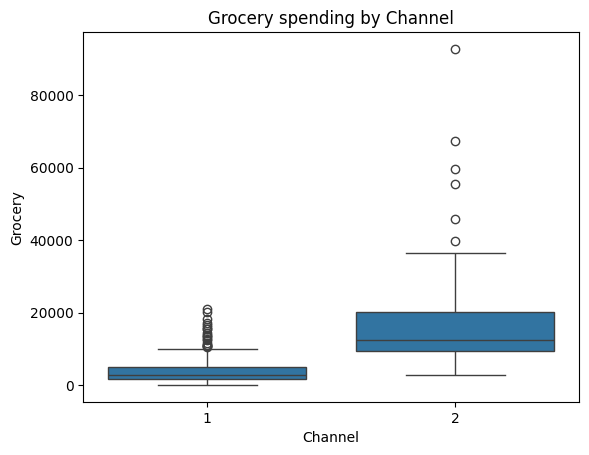

In [ ]:
sns.boxplot(x='Channel', y='Grocery' , data=df)
plt.title("Grocery spending by Channel")
plt.show()

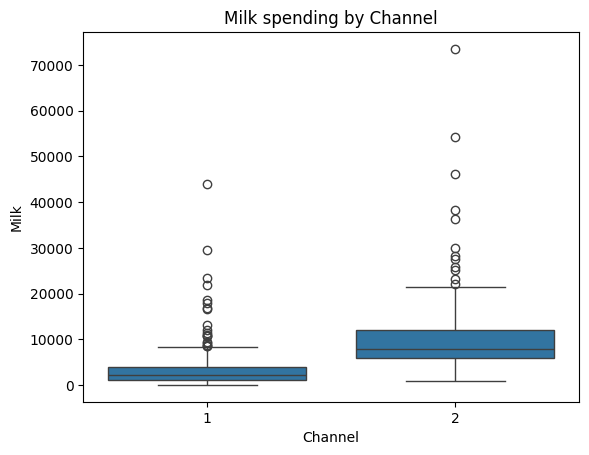

In [ ]:
sns.boxplot(x='Channel',y='Milk',data=df)
plt.title("Milk spending by Channel")
plt.show()

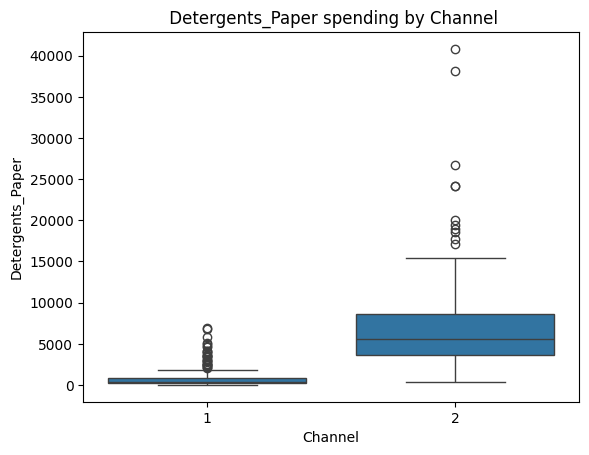

In [ ]:
sns.boxplot(x='Channel',y='Detergents_Paper',data=df)
plt.title(" Detergents_Paper spending by Channel")
plt.show()

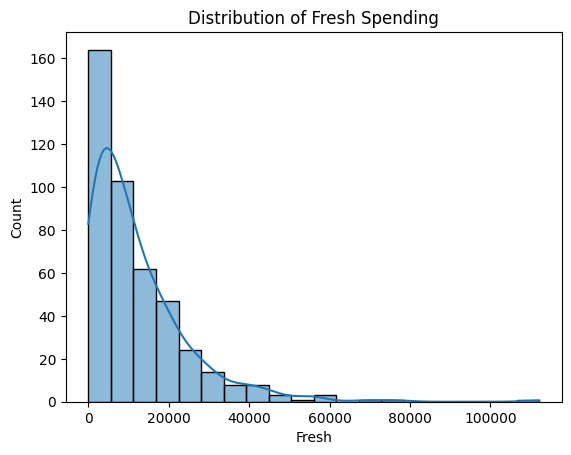

In [ ]:
sns.histplot(df["Fresh"], bins=20, kde=True)
plt.title("Distribution of Fresh Spending")
plt.show()

**NOTE**
- Most values are concentrated on the left side(low spending).There is a long tail extending to the right (few very high values like 60k, 80k, 100k+).
- When the tail extends to the right, it is called "Right-skewed[Positive skew]"
- Majority of customers spend lower amounts.Few customers spend extremely high amounts.
- These high spenders create the long right tail, mean > median usually in right-skewed data.
- Requires scaling,Because few extreme high values are present.

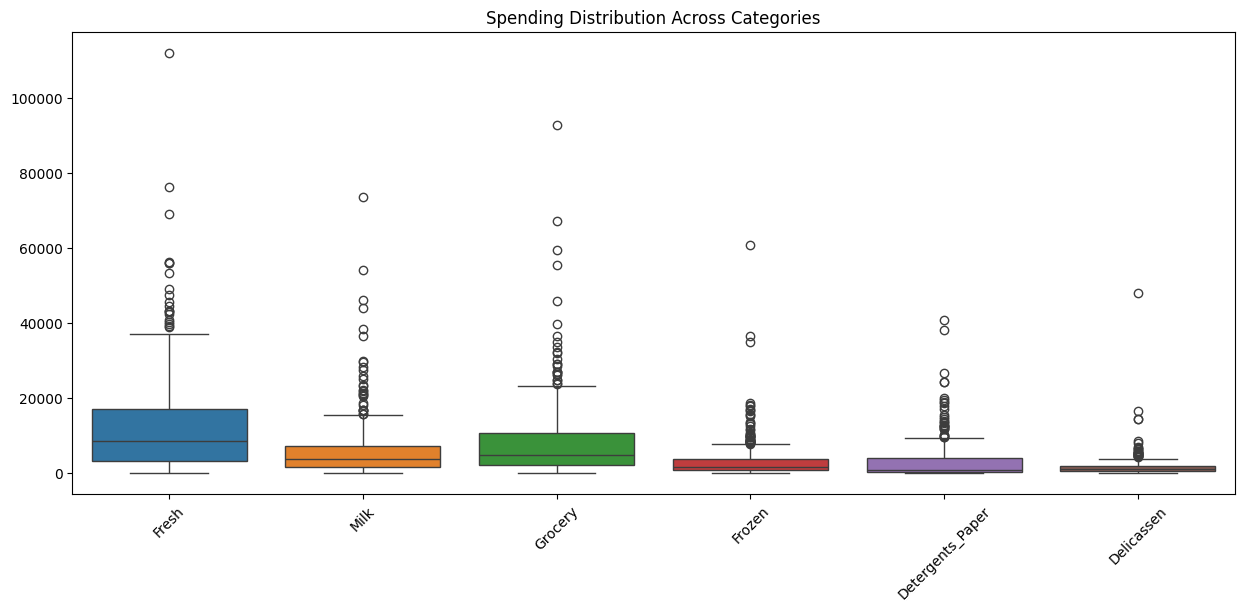

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']])
plt.xticks(rotation=45)
plt.title('Spending Distribution Across Categories')
plt.show()

**NOTE**

- Boxplots were used to visually detect outliers and compare variability across all spending categories. It confirmed high variability in Fresh and Grocery categories.

**Model Selection**

In [ ]:
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']

**LogisticRegression**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
model=LogisticRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))

confusion_matrix: [[89  5]
 [ 7 31]]
classification_report:               precision    recall  f1-score   support

           1       0.93      0.95      0.94        94
           2       0.86      0.82      0.84        38

    accuracy                           0.91       132
   macro avg       0.89      0.88      0.89       132
weighted avg       0.91      0.91      0.91       132

accuracy_score: 0.9090909090909091


**DecisionTree**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))




accuracy_score: 0.8257575757575758
confusion_matrix: [[80 14]
 [ 9 29]]
classification_report:               precision    recall  f1-score   support

           1       0.90      0.85      0.87        94
           2       0.67      0.76      0.72        38

    accuracy                           0.83       132
   macro avg       0.79      0.81      0.80       132
weighted avg       0.83      0.83      0.83       132



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model=DecisionTreeClassifier(criterion='entropy',max_depth=8)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))

accuracy_score: 0.8712121212121212
confusion_matrix: [[83 11]
 [ 6 32]]
classification_report:               precision    recall  f1-score   support

           1       0.93      0.88      0.91        94
           2       0.74      0.84      0.79        38

    accuracy                           0.87       132
   macro avg       0.84      0.86      0.85       132
weighted avg       0.88      0.87      0.87       132



**RandomForest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(model.feature_importances_)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))


[0.01557447 0.05469728 0.15806713 0.23442093 0.0613512  0.42490261
 0.05098638]
confusion_matrix: [[58  7]
 [ 2 21]]
classification_report:               precision    recall  f1-score   support

           1       0.97      0.89      0.93        65
           2       0.75      0.91      0.82        23

    accuracy                           0.90        88
   macro avg       0.86      0.90      0.88        88
weighted avg       0.91      0.90      0.90        88

accuracy_score: 0.8977272727272727


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestClassifier(n_estimators=7,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(model.feature_importances_)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))

[0.01210733 0.07728688 0.22987613 0.15347987 0.05512089 0.40056034
 0.07156857]
confusion_matrix: [[57  8]
 [ 2 21]]
classification_report:               precision    recall  f1-score   support

           1       0.97      0.88      0.92        65
           2       0.72      0.91      0.81        23

    accuracy                           0.89        88
   macro avg       0.85      0.89      0.86        88
weighted avg       0.90      0.89      0.89        88

accuracy_score: 0.8863636363636364


**XGBoost**

In [ ]:
from xgboost  import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel'] - 1 # Subtract 1 from Channel values to make them 0 and 1
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=XGBClassifier()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print(model.feature_importances_)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))

[0.04183464 0.06296405 0.06858154 0.04748661 0.04783158 0.70565116
 0.02565049]
confusion_matrix: [[59  6]
 [ 2 21]]
classification_report:               precision    recall  f1-score   support

           0       0.97      0.91      0.94        65
           1       0.78      0.91      0.84        23

    accuracy                           0.91        88
   macro avg       0.87      0.91      0.89        88
weighted avg       0.92      0.91      0.91        88

accuracy_score: 0.9090909090909091


**Support Vector Machine(SVM)**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
model=SVC()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))


confusion_matrix: [[58  7]
 [ 2 21]]
classification_report:               precision    recall  f1-score   support

           1       0.97      0.89      0.93        65
           2       0.75      0.91      0.82        23

    accuracy                           0.90        88
   macro avg       0.86      0.90      0.88        88
weighted avg       0.91      0.90      0.90        88

accuracy_score: 0.8977272727272727


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
model=SVC(kernel='linear')
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))


confusion_matrix: [[58  7]
 [ 3 20]]
classification_report:               precision    recall  f1-score   support

           1       0.95      0.89      0.92        65
           2       0.74      0.87      0.80        23

    accuracy                           0.89        88
   macro avg       0.85      0.88      0.86        88
weighted avg       0.90      0.89      0.89        88

accuracy_score: 0.8863636363636364


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
model=SVC(kernel='poly')
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))


confusion_matrix: [[63  2]
 [13 10]]
classification_report:               precision    recall  f1-score   support

           1       0.83      0.97      0.89        65
           2       0.83      0.43      0.57        23

    accuracy                           0.83        88
   macro avg       0.83      0.70      0.73        88
weighted avg       0.83      0.83      0.81        88

accuracy_score: 0.8295454545454546


**Performance Comparison**
- Logistic Regression and XGBoost achieved the highest **accuracy (91%)**.
- Random Forest and SVM also performed well with around **90% accuracy**.
- Decision Tree showed slightly lower performance due to potential overfitting.

**Final Model Selection**
The Logistic Regression model was selected as the final model because:
- It achieved high accuracy (91%).
-	It is simple and interpretable.
- It performs well with scaled numerical features.
- It allows understanding of how spending features influence predictions.



**Plotting For Logistic Regression**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
model=LogisticRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))

confusion_matrix: [[89  5]
 [ 7 31]]
classification_report:               precision    recall  f1-score   support

           1       0.93      0.95      0.94        94
           2       0.86      0.82      0.84        38

    accuracy                           0.91       132
   macro avg       0.89      0.88      0.89       132
weighted avg       0.91      0.91      0.91       132

accuracy_score: 0.9090909090909091


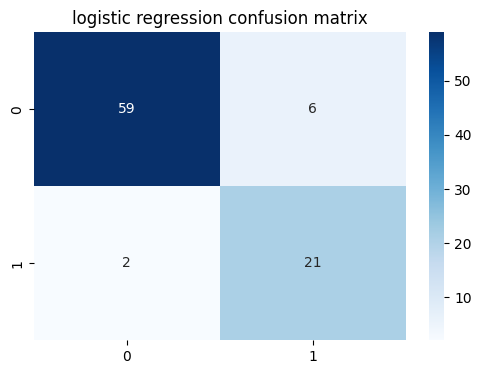

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred) # It compare actual vs predict values
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('logistic regression confusion matrix')
plt.show()

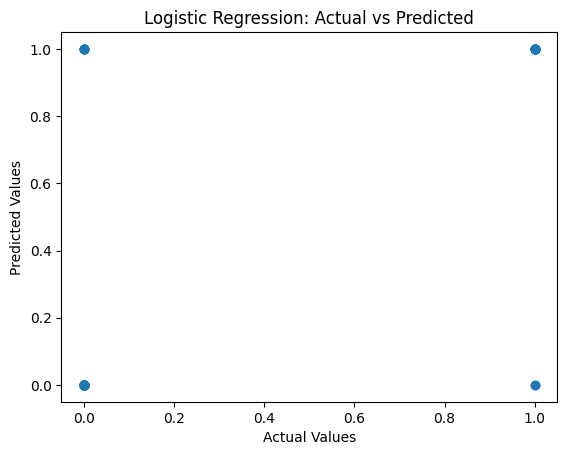

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.title("Logistic Regression: Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

**Plotting For XGBoost**

In [ ]:
from xgboost  import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel'] - 1 # Subtract 1 from Channel values to make them 0 and 1
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=XGBClassifier()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print(model.feature_importances_)
print('confusion_matrix:',confusion_matrix(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('accuracy_score:',accuracy_score(y_test,y_pred))

[0.04183464 0.06296405 0.06858154 0.04748661 0.04783158 0.70565116
 0.02565049]
confusion_matrix: [[59  6]
 [ 2 21]]
classification_report:               precision    recall  f1-score   support

           0       0.97      0.91      0.94        65
           1       0.78      0.91      0.84        23

    accuracy                           0.91        88
   macro avg       0.87      0.91      0.89        88
weighted avg       0.92      0.91      0.91        88

accuracy_score: 0.9090909090909091


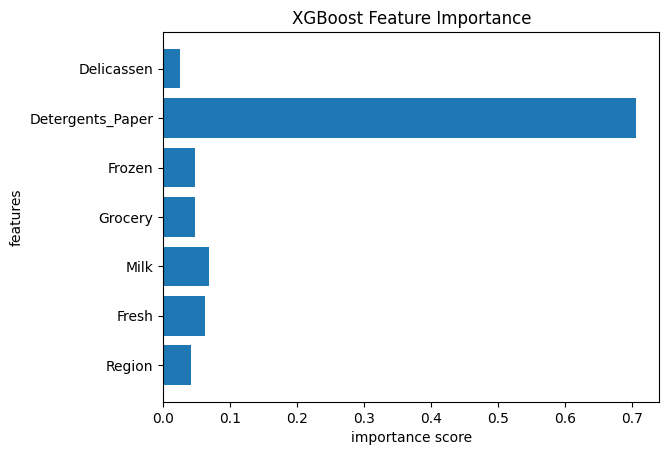

In [ ]:
importance=model.feature_importances_
features=X.columns
plt.barh(features,importance)
plt.title('XGBoost Feature Importance')
plt.xlabel('importance score')
plt.ylabel('features')
plt.show()